In [1]:
#load the dataset
import pandas as pd

df = pd.read_csv("../data/blood_demand_data.csv")

df.head()

,date,O+,A+,B+,AB+
0,2023-01-01,9,8,2,1
1,2023-01-02,13,12,3,1
2,2023-01-03,12,11,3,1
3,2023-01-04,19,18,5,2
4,2023-01-05,13,12,3,1


In [13]:
#train the model for all blood groups
from prophet import Prophet

blood_types = ["O+","A+","B+","AB+"]

predictions = {}
predictions_uncertainty = {}

for bt in blood_types:

    df_prophet = df[['date', bt]].rename(columns={
        "date":"ds",
        bt:"y"
    })

    model = Prophet()
    model.fit(df_prophet)

    future = model.make_future_dataframe(periods=30)

    forecast = model.predict(future)

    predictions[bt] = forecast[['ds','yhat']].tail(30)
    predictions_uncertainty [bt] = forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

predictions

14:37:23 - cmdstanpy - INFO - Chain [1] start processing
14:37:23 - cmdstanpy - INFO - Chain [1] done processing
14:37:23 - cmdstanpy - INFO - Chain [1] start processing
14:37:24 - cmdstanpy - INFO - Chain [1] done processing
14:37:24 - cmdstanpy - INFO - Chain [1] start processing
14:37:24 - cmdstanpy - INFO - Chain [1] done processing
14:37:24 - cmdstanpy - INFO - Chain [1] start processing
14:37:24 - cmdstanpy - INFO - Chain [1] done processing


{'O+':             ds       yhat
 731 2025-01-01  16.722248
 732 2025-01-02  17.475265
 733 2025-01-03  17.523512
 734 2025-01-04  15.057849
 735 2025-01-05  14.485243
 736 2025-01-06  17.496435
 737 2025-01-07  17.110211
 738 2025-01-08  17.037854
 739 2025-01-09  17.682358
 740 2025-01-10  17.618413
 741 2025-01-11  15.039362
 742 2025-01-12  14.354651
 743 2025-01-13  17.257432
 744 2025-01-14  16.768786
 745 2025-01-15  16.602119
 746 2025-01-16  17.162332
 747 2025-01-17  17.025760
 748 2025-01-18  14.387101
 749 2025-01-19  13.656832
 750 2025-01-20  16.528796
 751 2025-01-21  16.024413
 752 2025-01-22  15.857073
 753 2025-01-23  16.431313
 754 2025-01-24  16.322773
 755 2025-01-25  13.725140
 756 2025-01-26  13.047602
 757 2025-01-27  15.982469
 758 2025-01-28  15.549424
 759 2025-01-29  15.459965
 760 2025-01-30  16.116629,
 'A+':             ds       yhat
 731 2025-01-01  15.633946
 732 2025-01-02  16.260713
 733 2025-01-03  16.364127
 734 2025-01-04  13.981381
 735 2025-01-05

In [14]:
##forecast future blood demand with uncertainty
predictions_uncertainty

{'O+':             ds       yhat  yhat_lower  yhat_upper
 756 2025-01-26  13.047602    8.387927   17.702610
 757 2025-01-27  15.982469   11.393526   20.304371
 758 2025-01-28  15.549424   11.103674   20.103490
 759 2025-01-29  15.459965   11.040563   20.133430
 760 2025-01-30  16.116629   11.337610   20.993846,
 'A+':             ds       yhat  yhat_lower  yhat_upper
 756 2025-01-26  11.838040    7.355653   15.858713
 757 2025-01-27  14.544816   10.281631   18.805932
 758 2025-01-28  14.208600    9.974382   18.683544
 759 2025-01-29  14.225408   10.219270   18.651424
 760 2025-01-30  14.779253   10.300854   18.797627,
 'B+':             ds      yhat  yhat_lower  yhat_upper
 756 2025-01-26  3.287464    2.051313    4.493223
 757 2025-01-27  4.005240    2.716537    5.179660
 758 2025-01-28  3.907176    2.785126    5.114909
 759 2025-01-29  3.919146    2.728964    5.130454
 760 2025-01-30  4.019581    2.849758    5.280896,
 'AB+':             ds      yhat  yhat_lower  yhat_upper
 756 2025-

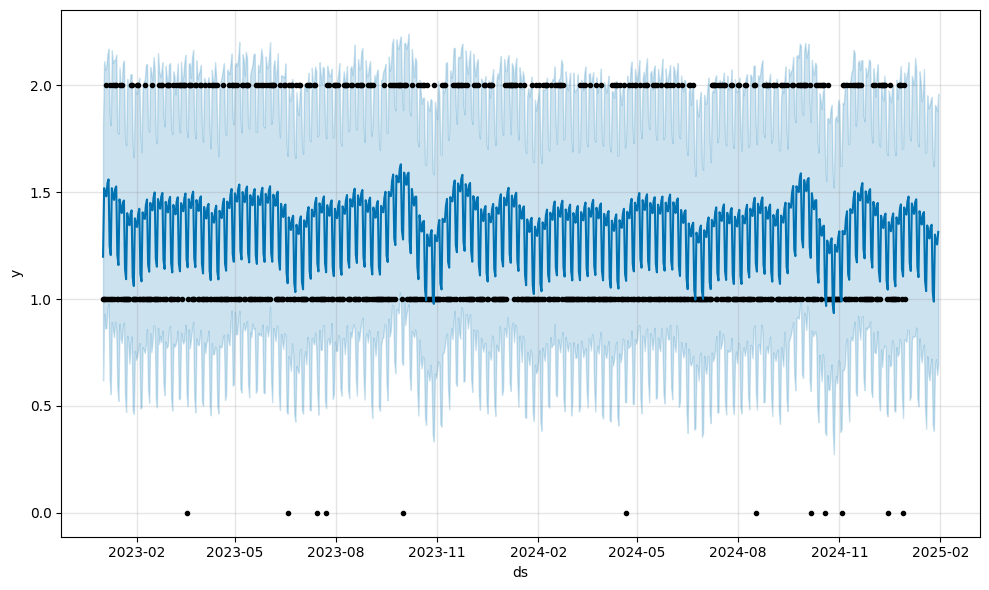

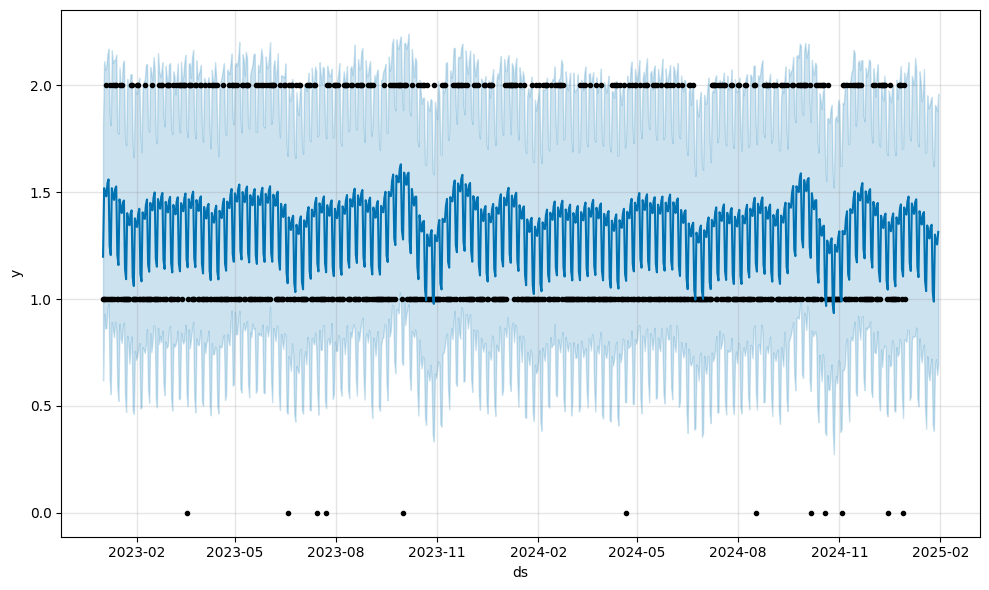

In [15]:
model.plot(forecast)

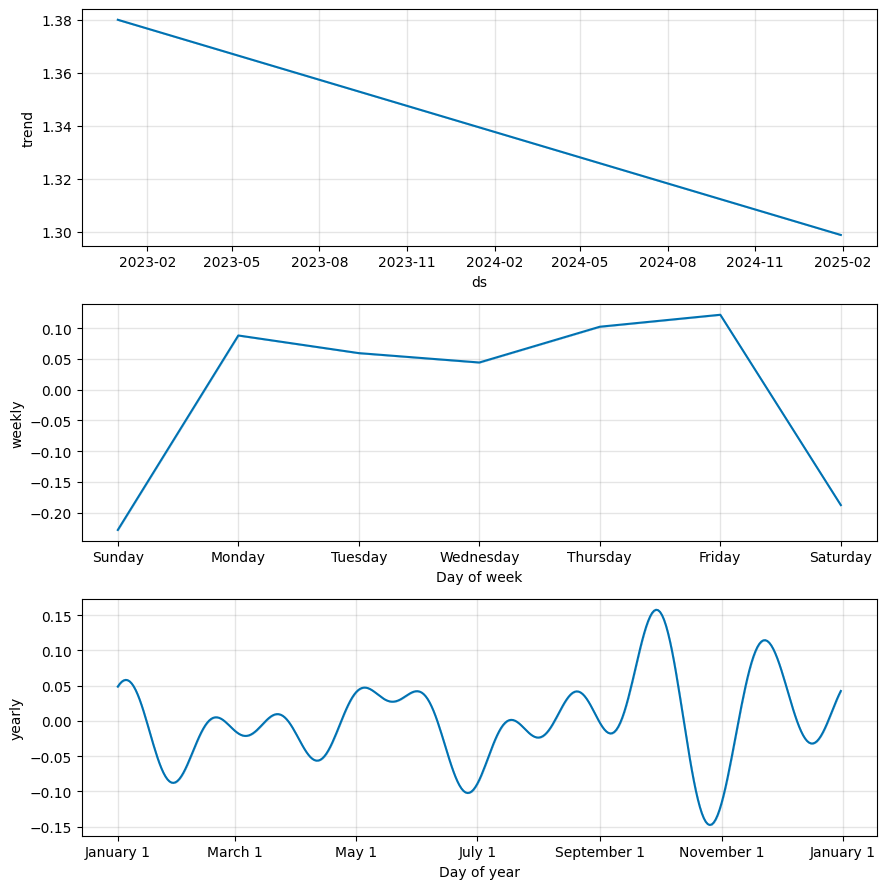

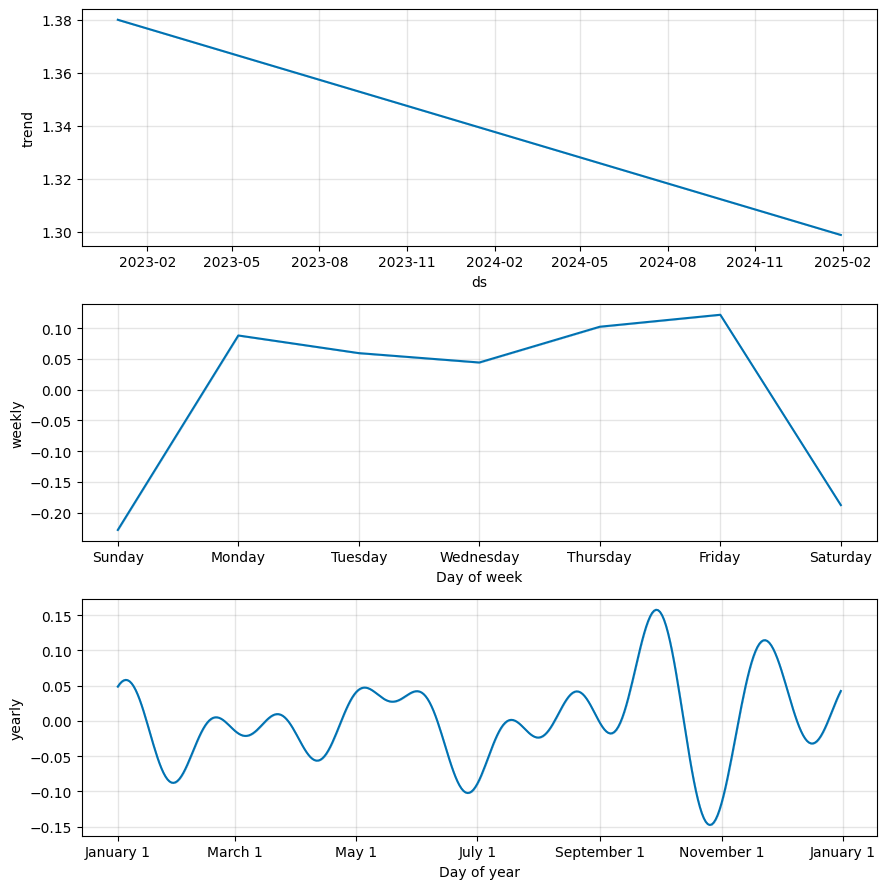

In [16]:
#This shows the patterns the model learned: weekly pattern, yearly trend, seasonal changes
model.plot_components(forecast)

In [17]:
forecast[['ds','yhat']].to_csv("../data/predicted_demand.csv", index=False)

In [18]:
import pickle

with open("../model/prophet_O_model.pkl","wb") as f:
    pickle.dump(model,f)